# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import math

# Graphiz Helper Function for Gradient Flow Graph

In [2]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

# Required Classes for Micrograd

### Value Class which acts as a Data structure

In [8]:
class Value:
    # Constructor
    def __init__(self, data: float, label: str="", _op: str="", _children: tuple=()):
        # public members
        self.data = data
        self.label = label
        self.grad = 0.0
        # protected members
        self._op = _op
        self._backward = lambda: None
        self._prev = set(_children)

    # special/dunder method for returning the string representation of an object 
    def __repr__(self):
        return f"Value.data = {self.data}"

    # Micro methods for algebraic operations

    # addition
    def __add__(self, other):
        # type casting for edge case Value+int/float
        other = Value(other) if not isinstance(other, Value) else other

        # performing addition
        out = Value((self.data + other.data), _op="+", _children=(self, other))

        # calculating gradient for addition operation => gradient of output flows back as it is to operands
        # storing the calculation as a callback function for back-propagation
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0

        # setting the callback as the object's _backward function
        out._backward = _backward

        return out

    # reverse addition to handle the edge case int/float+Value
    def __radd__(self, other):
        # here the self and other are exchanged with each other
        return self + other

    # multiplication
    def __mul__(self, other):
        # type casting for edge case Value*int/float
        other = Value(other) if not isinstance(other, Value) else other

        # performing multiplication
        out = Value((self.data * other.data), _op="*", _children=(self, other))

        # calculating gradient for multiplication operation => gradient of output flows back to operands and multiplied by the other operand's data
        # storing the calculation as a callback function for back-propagation
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data

        # setting the callback as the object's _backward function
        out._backward = _backward

        return out

    # reverse multiplication to handle the edge case int/float*Value
    def __rmul__(self, other):
        # here the self and other are exchanged with each other
        return self * other

    # exponentiation
    def __pow__(self, other):
        # making sure that the other is never a Value object
        assert isinstance(other, (int, float))

        # performing exponentiation
        out = Value((self.data ** other), _op=f"pow({other})", _children=(self,))

        # calculating gradient for exponentiation operation 
        # storing the calculation as a callback function for back-propagation
        def _backward():
            self.grad += out.grad * other * (self.data ** (other - 1))

        # setting the callback as the object's _backward function
        out._backward = _backward

        return out

    # subtraction
    def __sub__(self, other):
        return self + (-1 * other) # using the already built methods

    # reverse subtraction to handle the edge case int/float-Value
    def __rsub__(self, other):
        # here the self and other are exchanged with each other
        return (self * -1) + other

    def __truediv__(self, other):
        # type casting for edge case Value*int/float
        other = Value(other) if not isinstance(other, Value) else other

        # using the multiplication for division
        return self * (other ** -1)

    def __rtruediv__(self, other):
        # here the self and other are exchanged with each other
        return (self ** -1) * other

    # now implementing activation functions i.e. relu, sigmoid, and tanh

    # tanh implementation
    def tanh(self):
        out = Value((math.tanh(self.data)), _op="tanh", _children=(self,))

        def _backward():
            self.grad += (1 - out.data**2) * out.grad

        out._backward = _backward

        return out

    # relu implementation
    def relu(self):
        out = Value(max(0, self.data), _op="relu", _children=(self,))

        def _backward():
            self.grad += (self.data > 0) * out.grad

        out._backward = _backward

        return out

    # sigmoid implementation
    def sigmoid(self):
        z = 1 / (1 + math.exp(-self.data))

        out = Value(z, _op="sigmoid", _children=(self,))

        def _backward():
            self.grad += z * (1 - z) * out.grad

        out._backward = _backward

        return out

    # now implementing the main backward function with topological sorting
    def backward(self):
        nodes: list[Value] = [] # holds the soreted Value nodes
        visited = set()

        # topological sorting
        def topo_sort(node: Value):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    topo_sort(child)
                nodes.append(node)

        # initializing last neuron's gradient to 1.0
        self.grad = 1.0
        topo_sort(self)

        # calling the _backward callback for every node starting from the last one
        for node in reversed(nodes):
            node._backward()

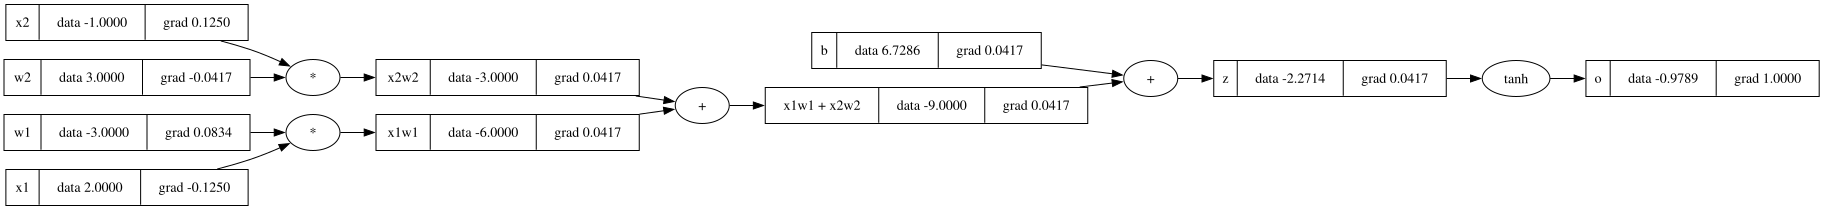

In [10]:
# inputs
x1 = Value(2.0, label="x1")
x2 = Value(-1.0, label="x2")

# weights and bias
w1 = Value(-3.0, label="w1")
w2 = Value(3.0, label="w2")
b = Value(6.7286, label="b")

# z = x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = "x1w1"
x2w2 = x2 * w2
x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1w1 + x2w2"

z = x1w1x2w2 + b
z.label = "z"

# applying the tanh activation function (o = z.tanh())
o = z.tanh()
o.label = "o"

o.backward()

draw_dot(o)

### Neuron Class which is a singular unit in a Neural Net

In [27]:
class Neuron:
    def __init__(self, n:int):
        # a neuron gets an 'n' dimensional input and it processes it with its weights and bias
        self.in_size = n
        # randomly initializing parameters i.e. weights and biases
        self.weights = [Value(np.random.uniform(-1, 1)) for _ in range(n)]
        self.bias = Value(np.random.uniform(-1, 1))

    # this function will get the input array 'x' and will return the output
    # output will be f(w*x + b), where f is the activation function
    def __call__(self, x: list):
        out = sum(((wi*xi) for wi, xi in zip(self.weights, x)), self.bias)
        return out.tanh()
    
    # this function will return the parameters in the Neuron
    def parameters(self):
        return self.weights + [self.bias]

### Layer class which holds 'n' number of Neurons

In [17]:
class Layer:
    def __init__(self, in_size:int, out_size:int):
        # a layer will get an input size and an output size
        self.in_size = in_size
        self.out_size = out_size
        # and it will have a list of neurons that have the dimensions out_size * 1
        self.neurons = [Neuron(in_size) for _ in range(out_size)]

    # this function will get the input array 'x' and will return the outputs of every neuron in it
    def __call__(self, x: list):
        return [neuron(x) for neuron in self.neurons]
    
    # this function will return the parameters in the Layer
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

### Multi-Layer Perceptron class

In [ ]:
class MLP:
    def __init__(self, in_size:int, out_sizes: list):
        # the MLP class gets in_size (the input 'x' dimension) and out_sizes (a list of sizes of individual layers in it)
        self.in_size = in_size
        self.out_sizes = out_sizes
        # and it creates a list of layers of those individual sizes
        self.layers = [Layer(in_size, out_sizes[i]) for i in range(len(out_sizes))]

    # this function will get the input array 'x' and will return the output of last layer in NN
    def __call__(self, x: list):
        for layer in self.layers:
            out = layer(x)
        return out

    # this function will return the parameters in the MLP
    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

# Testing the MLP

In [30]:
# input data
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.5, -1.0]
]

# original desired outputs
ys = [1.0, -1.0, -1.0, 1.0]

In [43]:
NN = MLP(3, [4, 4, 1])

# initial predictions from NN
y_pred = [NN(x) for x in xs]
y_pred

[[Value.data = -0.8641541918673193],
 [Value.data = 0.9827152233496105],
 [Value.data = 0.008428693257990925],
 [Value.data = -0.5444232909055529]]

In [44]:
# implementing the training loop
steps = 500
LR = 5e-3
losses = []

for i in range(steps):
    # forward pass
    y_pred = [NN(x)[0] for x in xs]

    # loss calculation using mean squared error
    loss = sum(((y_gt - y_out)**2 for y_gt, y_out in zip(ys, y_pred)), Value(0))
    losses.append(loss.data)
    print(f"Step: {i+1}, Learning Rate: {LR}, loss: {loss.data}")

    # zeroing out the gradients
    for param in NN.parameters():
        param.grad = 0.0

    # backward pass (back-propagation)
    loss.backward()

    # updating the gradients
    for param in NN.parameters():
        param.data += -LR * param.grad

Step: 1, Learning Rate: 0.005, loss: 10.808402238836353
Step: 2, Learning Rate: 0.005, loss: 10.529740010443486
Step: 3, Learning Rate: 0.005, loss: 10.181064562370388
Step: 4, Learning Rate: 0.005, loss: 9.739576594343383
Step: 5, Learning Rate: 0.005, loss: 9.183864657967675
Step: 6, Learning Rate: 0.005, loss: 8.514438266287621
Step: 7, Learning Rate: 0.005, loss: 7.791998895034271
Step: 8, Learning Rate: 0.005, loss: 7.14421839868346
Step: 9, Learning Rate: 0.005, loss: 6.669824359907621
Step: 10, Learning Rate: 0.005, loss: 6.359451827978684
Step: 11, Learning Rate: 0.005, loss: 6.1540652810842404
Step: 12, Learning Rate: 0.005, loss: 6.007243838434686
Step: 13, Learning Rate: 0.005, loss: 5.892943194673721
Step: 14, Learning Rate: 0.005, loss: 5.797555913990775
Step: 15, Learning Rate: 0.005, loss: 5.713877794807138
Step: 16, Learning Rate: 0.005, loss: 5.637959928086012
Step: 17, Learning Rate: 0.005, loss: 5.567559937315814
Step: 18, Learning Rate: 0.005, loss: 5.50136552518748

In [45]:
# final predictions by NN
y_pred

[Value.data = 0.9504444469738272,
 Value.data = -0.9456215495334098,
 Value.data = -0.8785972966832422,
 Value.data = 0.912393812616504]

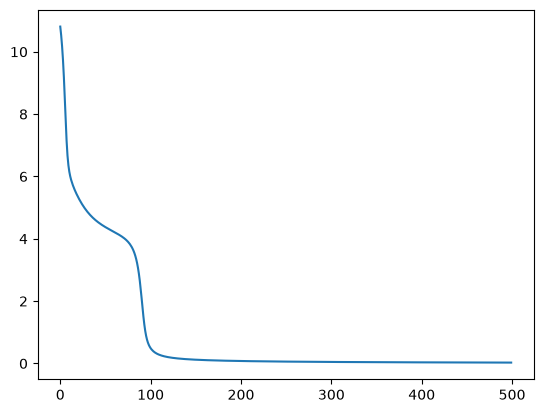

In [48]:
# loss graph

x_values = np.arange(0, steps)
plt.plot(x_values, losses)

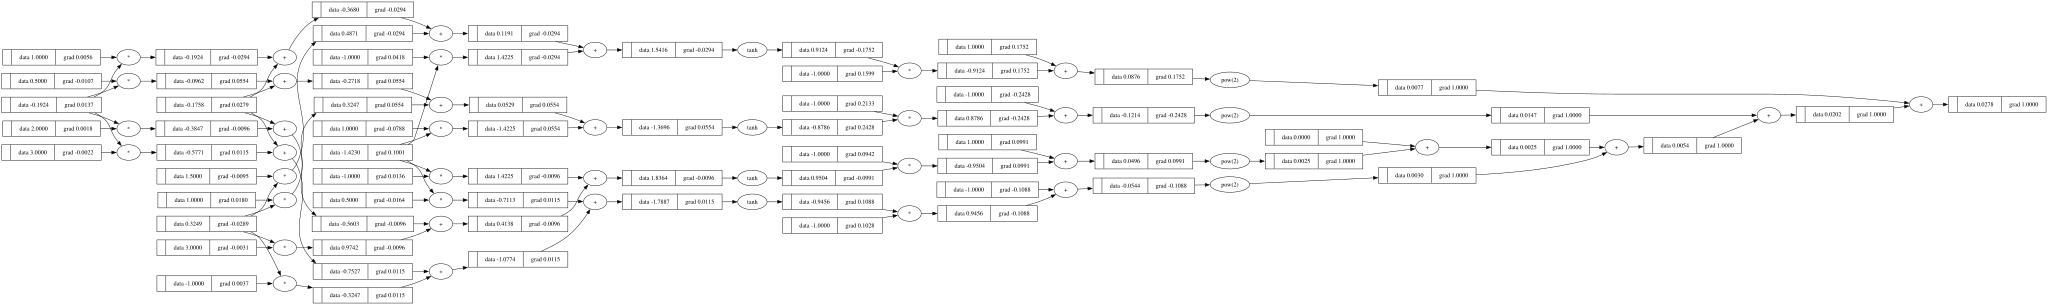

In [49]:
# final parameter values and their gradients
draw_dot(loss)